In [2]:
try: 
    import kagglehub #pip install kagglehub
    kagglehub.login()
    path = kagglehub.competition_download('aca-butterflies')
    print("Path to dataset files:", path)
    
except ImportError as e:
    from pathlib import Path
    path = Path().cwd()  / "aca-butterflies"

In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

In [4]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [5]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [6]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [7]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


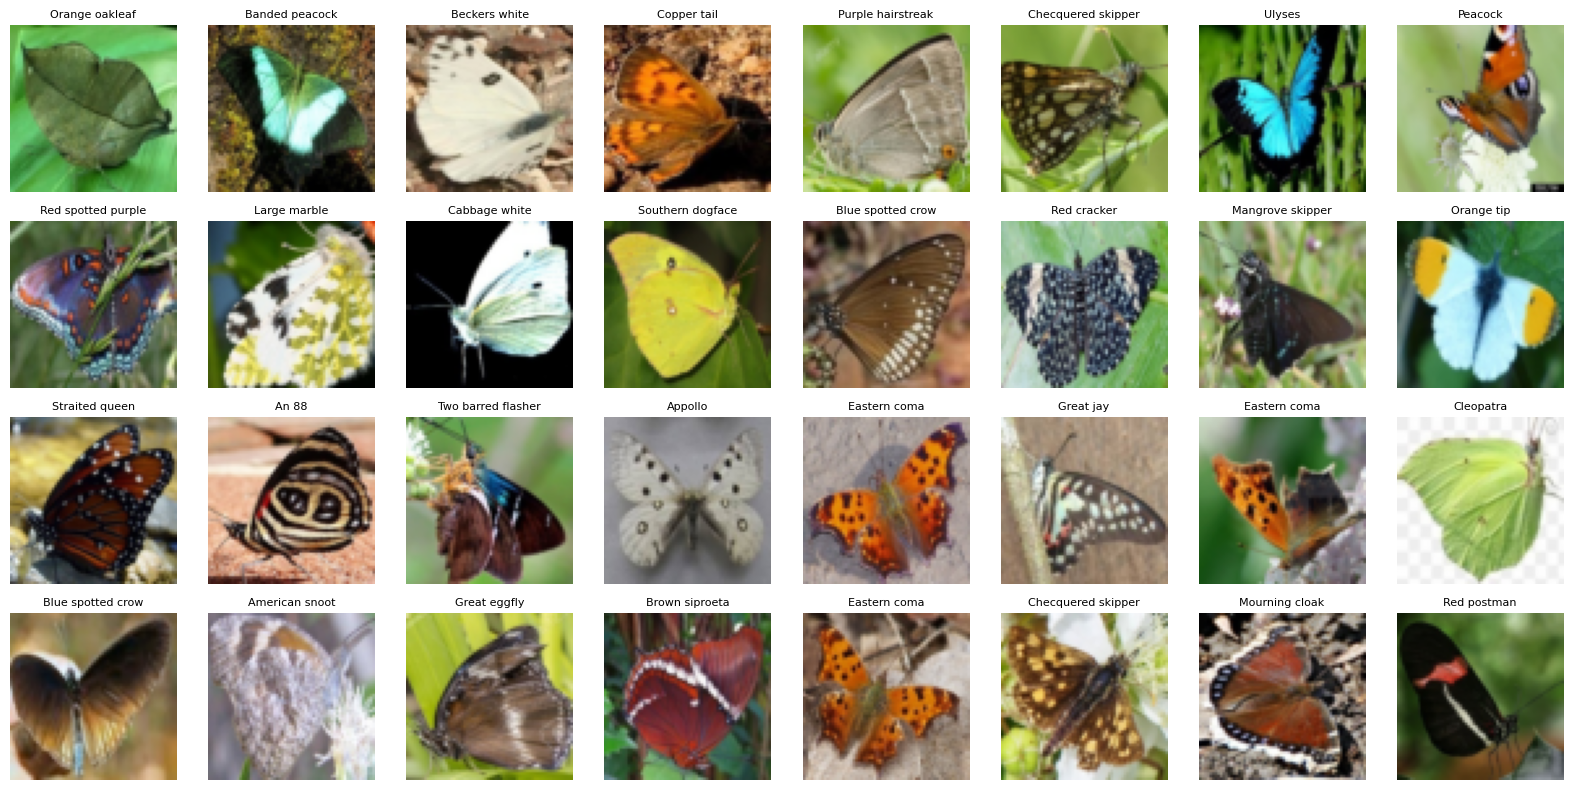

In [8]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Dataset Split

In [9]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# stratified split
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df['label'],   # coluna com as classes
    random_state=42
)

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# datasets
train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)

# dataloaders
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


# First Aproach

In [10]:
import numpy as np
import torch
import torchvision #carregar datasets
import torchvision.transforms as transforms # transforma os dados
import torch.nn as nn #bloco basico de contrsução de redes neurais
import torch.nn.functional as F #importa convulution functions como Relu
import torch.optim as optim # optimizadors
from multiprocessing import Process, freeze_support
from torch.utils.data import Dataset, DataLoader

In [ ]:
class Net(nn.Module):
    '''Models a simple Convolutional Neural Network'''

    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 13 * 13, 120)

        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 75)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 16 * 13 * 13)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RobustNet(nn.Module):

    def __init__(self, num_classes=75):
        super(RobustNet, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) 
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) 
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1) 

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(256 * 4 * 4, 512)  # ajustado após pooling
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Convolutional blocks
        x = F.relu(self.conv1(x))
        x = self.pool(x)  # 64 -> 32

        x = F.relu(self.conv2(x))
        x = self.pool(x)  # 32 -> 16

        x = F.relu(self.conv3(x))
        x = self.pool(x)  # 16 -> 8

        x = F.relu(self.conv4(x))
        x = self.pool(x)  # 8 -> 4

        # Flatten
        x = x.view(-1, 256 * 4 * 4)

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)  # sem ReLU final, pois CrossEntropyLoss já faz softmax

        return x


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SuperNet(nn.Module):
    '''High-performance CNN for 64x64 images, 75 classes'''

    def __init__(self, num_classes=75):
        super(SuperNet, self).__init__()

        # --- Convolutional Block 1 ---
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)  # 64 -> 32
        )

        # --- Convolutional Block 2 ---
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)  # 32 -> 16
        )

        # --- Convolutional Block 3 ---
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)  # 16 -> 8
        )

        # --- Convolutional Block 4 ---
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1,1))  # global average pooling
        )

        # --- Fully Connected Layer ---
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        # Inicialização He
        self._initialize_weights()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.fc(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, a=0, nonlinearity='relu')
                nn.init.zeros_(m.bias)

### CNN with Optuna

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import optuna
import time
import matplotlib.pyplot as plt
import pandas as pd

# DEVICE (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# MODEL
class SuperNet(nn.Module):
    def __init__(self, config, num_classes=75, folder="Results/CNN/", filename=None, plot=True):
        super(SuperNet, self).__init__()

        k = config["kernel_size"]
        p = k // 2
        s = config["stride"]
        pool = config["pool"]
        dropout = config["dropout"]
        self.filename = filename    # Name of CSV and PTH file
        self.folder = folder
        self.plot = plot

        c1, c2, c3, c4 = config["channels"]

        def get_pool():
            return nn.MaxPool2d(2,2) if pool == "max" else nn.AvgPool2d(2,2)

        self.block1 = nn.Sequential(
            nn.Conv2d(3, c1, k, stride=s, padding=p),
            nn.BatchNorm2d(c1),
            nn.ReLU(),
            nn.Conv2d(c1, c1, k, padding=p),
            nn.BatchNorm2d(c1),
            nn.ReLU(),
            get_pool()
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(c1, c2, k, stride=s, padding=p),
            nn.BatchNorm2d(c2),
            nn.ReLU(),
            nn.Conv2d(c2, c2, k, padding=p),
            nn.BatchNorm2d(c2),
            nn.ReLU(),
            get_pool()
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(c2, c3, k, padding=p),
            nn.BatchNorm2d(c3),
            nn.ReLU(),
            nn.Conv2d(c3, c3, k, padding=p),
            nn.BatchNorm2d(c3),
            nn.ReLU(),
            get_pool()
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(c3, c4, k, padding=p),
            nn.BatchNorm2d(c4),
            nn.ReLU(),
            nn.Conv2d(c4, c4, k, padding=p),
            nn.BatchNorm2d(c4),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(c4, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.fc(x)
        return x

# TRAIN + EVAL
def evaluate(model, dataloader, criterion):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    loss_avg = loss_total / len(dataloader)
    return acc, loss_avg


# FIT FUNCTION (EARLY STOP + PRUNING)
def fit(model, train_loader, val_loader, optimizer, criterion, trial,
        epochs=20, patience=5, folder="Results/CNN/", filename=None, plot=True):


    train_acc_graph, val_acc_graph = [], []
    train_loss_graph, val_loss_graph = [], []
    time_values = []

    best_val_loss = float("inf")
    best_val_acc = 0
    p = 0

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_acc, _ = evaluate(model, train_loader, criterion)
        val_acc, val_loss = evaluate(model, val_loader, criterion)
        train_loss = total_loss / len(train_loader)

        # PRUNING (Optuna)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            p = 0
        else:
            p += 1

        if p >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        # STORE
        train_acc_graph.append(train_acc * 100)
        val_acc_graph.append(val_acc * 100)
        train_loss_graph.append(train_loss)
        val_loss_graph.append(val_loss)
        time_values.append(time.time() - start_time)

        print(f"[{epoch+1}] Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

    # PLOTS
    plt.figure()
    plt.plot(train_acc_graph, label="Train Acc")
    plt.plot(val_acc_graph, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.savefig(folder + f"acc_{filename}.png")
    plt.close()

    plt.figure()
    plt.plot(train_loss_graph, label="Train Loss")
    plt.plot(val_loss_graph, label="Val Loss")
    plt.legend()
    plt.title("Loss")
    plt.savefig(folder + f"loss_{filename}.png")
    plt.close()

    df = pd.DataFrame({"train_acc": train_acc_graph, "val_acc": val_acc_graph, "train_loss": train_loss_graph, "val_loss": val_loss_graph, "time": time_values})
    if filename is not None:
        df.to_csv(folder + filename + ".csv", index=True, index_label="epoch")

    
    return best_val_acc



Using device: cuda


In [ ]:
# OPTUNA OBJECTIVE
def objective(trial):

    config = {
        "kernel_size": trial.suggest_categorical("kernel_size", [3,5]),
        "stride": trial.suggest_categorical("stride", [1,2]),
        "pool": trial.suggest_categorical("pool", ["max","avg"]),
        "dropout": trial.suggest_float("dropout", 0.2, 0.6),

        "channels": [
            trial.suggest_categorical("c1", [32,64]),
            trial.suggest_categorical("c2", [64,128]),
            trial.suggest_categorical("c3", [128,256]),
            trial.suggest_categorical("c4", [256,512])
        ],

        "lr": trial.suggest_float("lr", 1e-5, 1e-3, log=True),
        "patience": trial.suggest_int("patience", 2, 10)
    }

    model = SuperNet(config, filename=f"trial_{trial.number}", plot=False).to(device)

    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.CrossEntropyLoss()

    acc = fit(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        trial,
        epochs=50,
        patience=config["patience"],
        folder="Results/CNN/",
        filename=f"trial_{trial.number}",
        plot=False
    )

    return acc


# RUN STUDY
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=30)

print("Best trial:", study.best_trial.params)

[I 2026-04-09 18:00:52,011] A new study created in memory with name: no-name-32e90dee-1591-473a-b903-829a0cfee10d


[1] Train Acc: 0.143 | Val Acc: 0.148
[2] Train Acc: 0.268 | Val Acc: 0.265
[3] Train Acc: 0.377 | Val Acc: 0.331
[4] Train Acc: 0.452 | Val Acc: 0.367
[5] Train Acc: 0.572 | Val Acc: 0.492
[6] Train Acc: 0.669 | Val Acc: 0.521
[7] Train Acc: 0.666 | Val Acc: 0.521
[8] Train Acc: 0.743 | Val Acc: 0.540
[9] Train Acc: 0.837 | Val Acc: 0.579
[10] Train Acc: 0.862 | Val Acc: 0.579
[11] Train Acc: 0.864 | Val Acc: 0.548
[12] Train Acc: 0.930 | Val Acc: 0.588
[13] Train Acc: 0.899 | Val Acc: 0.567
[14] Train Acc: 0.941 | Val Acc: 0.558
[15] Train Acc: 0.964 | Val Acc: 0.621
[16] Train Acc: 0.950 | Val Acc: 0.565
[17] Train Acc: 0.977 | Val Acc: 0.594
[18] Train Acc: 0.991 | Val Acc: 0.633
[19] Train Acc: 0.987 | Val Acc: 0.619
[20] Train Acc: 0.992 | Val Acc: 0.648


[I 2026-04-09 18:11:44,674] Trial 0 finished with value: 0.6480769230769231 and parameters: {'kernel_size': 5, 'stride': 2, 'pool': 'avg', 'dropout': 0.3067870504469429, 'c1': 32, 'c2': 128, 'c3': 256, 'c4': 512, 'lr': 0.00012028969765097044, 'patience': 7}. Best is trial 0 with value: 0.6480769230769231.


[1] Train Acc: 0.128 | Val Acc: 0.112
[2] Train Acc: 0.198 | Val Acc: 0.177
[3] Train Acc: 0.298 | Val Acc: 0.269
[4] Train Acc: 0.377 | Val Acc: 0.315
[5] Train Acc: 0.490 | Val Acc: 0.413
[6] Train Acc: 0.594 | Val Acc: 0.462
[7] Train Acc: 0.686 | Val Acc: 0.529
[8] Train Acc: 0.721 | Val Acc: 0.531
[9] Train Acc: 0.823 | Val Acc: 0.573
[10] Train Acc: 0.880 | Val Acc: 0.600
[11] Train Acc: 0.914 | Val Acc: 0.637
[12] Train Acc: 0.950 | Val Acc: 0.646
[13] Train Acc: 0.977 | Val Acc: 0.642
[14] Train Acc: 0.988 | Val Acc: 0.642
[15] Train Acc: 0.988 | Val Acc: 0.627
[16] Train Acc: 0.989 | Val Acc: 0.631
[17] Train Acc: 0.993 | Val Acc: 0.654
[18] Train Acc: 0.995 | Val Acc: 0.646
[19] Train Acc: 0.998 | Val Acc: 0.644
[20] Train Acc: 0.999 | Val Acc: 0.648


[I 2026-04-09 18:19:38,921] Trial 1 finished with value: 0.6442307692307693 and parameters: {'kernel_size': 3, 'stride': 2, 'pool': 'avg', 'dropout': 0.38892620302307224, 'c1': 64, 'c2': 128, 'c3': 256, 'c4': 256, 'lr': 8.737396890706906e-05, 'patience': 10}. Best is trial 0 with value: 0.6480769230769231.


[1] Train Acc: 0.089 | Val Acc: 0.077
[2] Train Acc: 0.118 | Val Acc: 0.121
[3] Train Acc: 0.148 | Val Acc: 0.144


[W 2026-04-09 18:20:35,498] Trial 2 failed with parameters: {'kernel_size': 3, 'stride': 1, 'pool': 'avg', 'dropout': 0.5769211116598318, 'c1': 32, 'c2': 128, 'c3': 128, 'c4': 512, 'lr': 2.2055903631565927e-05, 'patience': 3} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\João Cascais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\João Cascais\AppData\Local\Temp\ipykernel_48772\2044607495.py", line 26, in objective
    acc = fit(
          ^^^^
  File "C:\Users\João Cascais\AppData\Local\Temp\ipykernel_48772\13574179.py", line 142, in fit
    loss.backward()
  File "C:\Users\João Cascais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\_te

KeyboardInterrupt: 

### RESNET Sketch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Bloco Residual
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

# ------------------------
# Super ResNet-like Network
# ------------------------
class MegaNet(nn.Module):
    def __init__(self, num_classes=75):
        super(MegaNet, self).__init__()

        self.in_channels = 64

        # Entrada
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Blocos residuais
        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        # Global Average Pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        # Fully connected
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        self._initialize_weights()

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = self.fc(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, a=0, nonlinearity='relu')
                nn.init.zeros_(m.bias)


In [14]:
# Dispositivo: GPU se disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
NUM_CLASSES = 75
NUM_EPOCHS = 50

net = SuperNet(NUM_CLASSES).to(device)

# --------------------------
# LOSS E OPTIMIZER
# --------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# --------------------------
# TREINO E VALIDAÇÃO
# --------------------------
print("Starting training...")

for epoch in range(NUM_EPOCHS):
    print(f"\n========== EPOCH {epoch+1}/{NUM_EPOCHS} ==========")

    # -------------------
    # TREINO
    # -------------------
    net.train()
    running_loss = 0.0
    print("Starting TRAINING phase")

    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)

        loss.backward() 
        optimizer.step()

        running_loss += loss.item()

        if i % 50 == 0:
            print(f"Training batch {i+1}/{len(train_loader)}, current loss: {loss.item():.4f}")

    train_loss = running_loss / len(train_loader)
    print("Training phase finished")

    # -------------------
    # VALIDAÇÃO
    # -------------------
    net.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    print("Starting VALIDATION phase")

    with torch.no_grad():
        for i, data in enumerate(val_loader):
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)

            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if i % 20 == 0:
                print(f"Validation batch {i+1}/{len(val_loader)}, batch accuracy: {100*(predicted==labels).sum().item()/labels.size(0):.2f}%")

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct / total
    print("Validation phase finished")

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} results:")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_accuracy:.2f}%")

print("\nFinished Training")

Starting training...

========== EPOCH 1/50 ==========
Starting TRAINING phase
Training batch 1/147, current loss: 5.2577
Training batch 51/147, current loss: 4.1817
Training batch 101/147, current loss: 4.2574
Training phase finished
Starting VALIDATION phase
Validation batch 1/17, batch accuracy: 18.75%
Validation phase finished

Epoch 1/50 results:
Train Loss: 4.4767
Val Loss: 3.8471
Val Accuracy: 14.42%

========== EPOCH 2/50 ==========
Starting TRAINING phase
Training batch 1/147, current loss: 4.2804
Training batch 51/147, current loss: 4.0838
Training batch 101/147, current loss: 3.8140
Training phase finished
Starting VALIDATION phase
Validation batch 1/17, batch accuracy: 21.88%
Validation phase finished

Epoch 2/50 results:
Train Loss: 3.9901
Val Loss: 3.5267
Val Accuracy: 17.50%

========== EPOCH 3/50 ==========
Starting TRAINING phase
Training batch 1/147, current loss: 3.7550
Training batch 51/147, current loss: 3.9721
Training batch 101/147, current loss: 3.6738
Training 